# Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Inisialisasi File CSV

In [3]:
df = pd.read_csv("Indikator_Kesehatan_mhs.csv")
df.head()

,KabKot,H1. Persentase Jaminan Kesehatan,H2. Persentase Keluhan Kesehatan,H3. Persentase Kesakitan,H4. Jumlah Faskes,H5. Lama Rawat Inap,H6. Persentase Bayi Mendapatkan ASI sampai 1 tahun,H7. Persentase ASI sampai Baduta,H8. Rasio Dokter: Kecamatan,H9. Rasio Bidan:Desa/Kelurahan,...,H30. Persentase Pneumonia per Prediksi Terindikasi,H31. Persentase Diare Mendapat Pelayanan,H32. Persentase Hipertensi Mendapat Pelayanan,H33. Persentase DM Mendapat Pelayanan,H34. Persentase ODGJ Mendapat Pelayanan,H35. Persentase Sarana Air Minum Memenuhi Syarat,H36. Persentase Jamban Sehat,H37. Persentase Desa STBM,H38. TTU Memenuhi Syarat Kesehatan,H39. TPM Memenuhi Syarat Kesehatan
0,KAB. PACITAN,36.00,17.73,9.10,120.0,4.41,4.47,92.64,2.75,2.14,...,4.0,22.4,19.6,76.7,156.2,78.5,100.0,90.1,62.3,36.4
1,KAB. PONOROGO,127.28,39.59,18.92,210.0,4.16,3.45,96.11,8.81,1.99,...,43.9,36.1,15.0,86.4,138.2,98.0,100.0,100.0,59.7,53.5
2,KAB. TRENGGALEK,45.79,43.94,18.17,128.0,4.69,4.18,94.46,22.21,2.53,...,48.8,52.4,13.3,100.0,30.6,86.6,100.0,100.0,77.2,85.9
3,KAB. TULUNGAGUNG,99.88,NaN,19.19,135.0,5.05,4.18,100.00,8.58,2.26,...,36.8,59.8,73.6,155.2,111.2,62.2,87.7,81.2,81.8,78.6
4,KAB. BLITAR,64.09,39.66,18.17,98.0,4.43,3.62,92.10,23.18,2.27,...,45.4,29.6,33.1,97.5,94.9,75.9,96.4,86.7,79.1,63.5


# Check Missing Value

In [ ]:
df.isnull().sum()   

KabKot                                                0
H1. Persentase Jaminan Kesehatan                      0
H2. Persentase Keluhan Kesehatan                      3
H3. Persentase Kesakitan                              0
H4. Jumlah Faskes                                     1
H5. Lama Rawat Inap                                   4
H6. Persentase Bayi Mendapatkan ASI sampai 1 tahun    0
H7. Persentase ASI sampai Baduta                      0
H8. Rasio Dokter: Kecamatan                           0
H9. Rasio Bidan:Desa/Kelurahan                        2
H10. Rasio Jumlah Perawat:Kecamatan                   0
H11. Angka Kematian Netto                             0
H12. Rasio Posyandu Aktif:Desa/Kelurahan              0
H13. Persentase Ibu Mati Melahirkan                   3
H14. Rata-rata Persentase Ibu Hamil Imunisasi Td      0
H15. Persentase Penanganan Neonatal                   1
H16. Jumlah Bayi Mati Neonatal                        2
H17. Persen BBLR                                

# Handling Missing Value

In [8]:
df_filled = df.fillna(df.mean(numeric_only=True))
df_filled.head()

,KabKot,H1. Persentase Jaminan Kesehatan,H2. Persentase Keluhan Kesehatan,H3. Persentase Kesakitan,H4. Jumlah Faskes,H5. Lama Rawat Inap,H6. Persentase Bayi Mendapatkan ASI sampai 1 tahun,H7. Persentase ASI sampai Baduta,H8. Rasio Dokter: Kecamatan,H9. Rasio Bidan:Desa/Kelurahan,...,H30. Persentase Pneumonia per Prediksi Terindikasi,H31. Persentase Diare Mendapat Pelayanan,H32. Persentase Hipertensi Mendapat Pelayanan,H33. Persentase DM Mendapat Pelayanan,H34. Persentase ODGJ Mendapat Pelayanan,H35. Persentase Sarana Air Minum Memenuhi Syarat,H36. Persentase Jamban Sehat,H37. Persentase Desa STBM,H38. TTU Memenuhi Syarat Kesehatan,H39. TPM Memenuhi Syarat Kesehatan
0,KAB. PACITAN,36.00,17.730000,9.10,120.0,4.41,4.47,92.64,2.75,2.14,...,4.0,22.4,19.6,76.7,156.2,78.5,100.0,90.1,62.3,36.4
1,KAB. PONOROGO,127.28,39.590000,18.92,210.0,4.16,3.45,96.11,8.81,1.99,...,43.9,36.1,15.0,86.4,138.2,98.0,100.0,100.0,59.7,53.5
2,KAB. TRENGGALEK,45.79,43.940000,18.17,128.0,4.69,4.18,94.46,22.21,2.53,...,48.8,52.4,13.3,100.0,30.6,86.6,100.0,100.0,77.2,85.9
3,KAB. TULUNGAGUNG,99.88,33.219429,19.19,135.0,5.05,4.18,100.00,8.58,2.26,...,36.8,59.8,73.6,155.2,111.2,62.2,87.7,81.2,81.8,78.6
4,KAB. BLITAR,64.09,39.660000,18.17,98.0,4.43,3.62,92.10,23.18,2.27,...,45.4,29.6,33.1,97.5,94.9,75.9,96.4,86.7,79.1,63.5


# Variable X and Y

In [11]:
y = df_filled["H11. Angka Kematian Netto"]
x = df_filled[[
    "H4. Jumlah Faskes",
    "H8. Rasio Dokter: Kecamatan",
    "H9. Rasio Bidan:Desa/Kelurahan",
    "H10. Rasio Jumlah Perawat:Kecamatan",
    "H13. Persentase Ibu Mati Melahirkan",
    "H16. Jumlah Bayi Mati Neonatal",
    "H17. Persen BBLR",
    "H28. Jumlah Terduga TBC",
    "H29. Persentase Keberhasilan Pengobatan TBC",
    "H30. Persentase Pneumonia per Prediksi Terindikasi",
    "H35. Persentase Sarana Air Minum Memenuhi Syarat",
    "H36. Persentase Jamban Sehat"
]]

# Standarisasi 

In [16]:
scaler  = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Check Korelations

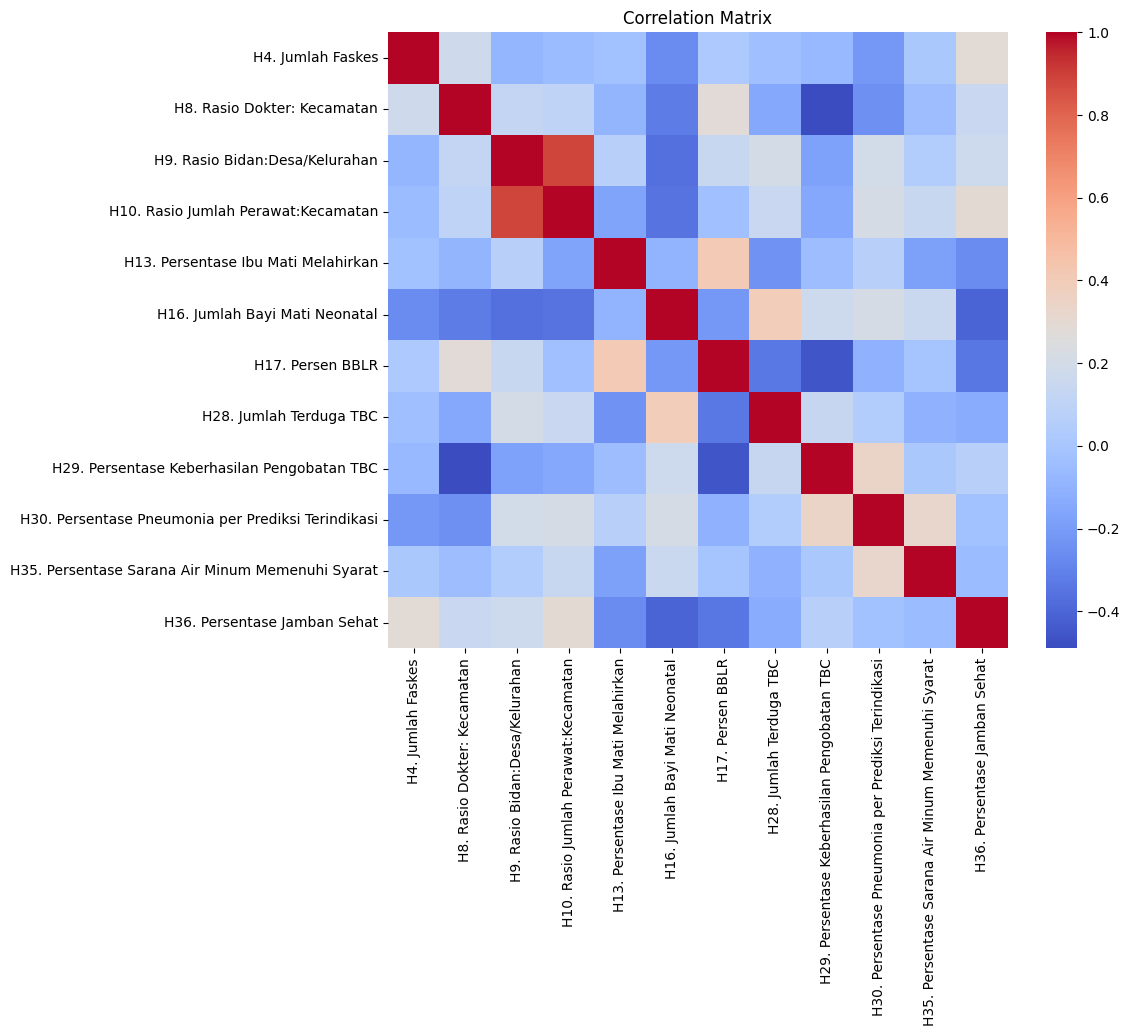

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(x_scaled, columns=x.columns).corr(),
            cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

# PCA

In [20]:
pca = PCA()
x_pca =  pca.fit_transform(x_scaled)

# All Componennt

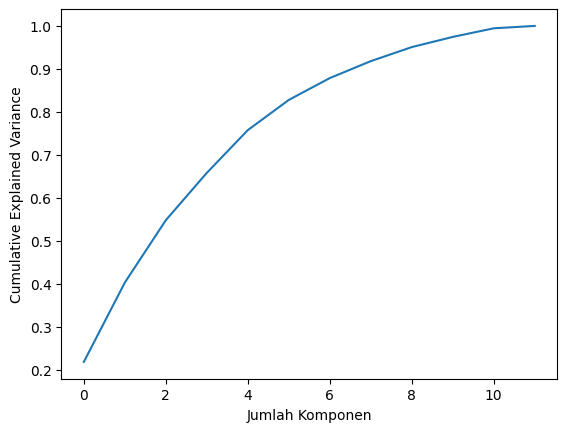

In [22]:
import numpy as np

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.show()